In [1]:
import pandas as pd
import geopandas as gpd

In [7]:
shell_path = ""
dbox_path = r'C:\Users\Anzony\Dropbox\sa_fires'
root = dbox_path
int_path = f"{root}/proj_bureaucrats_farms/data_output/intermediate"

In [3]:
df = pd.read_stata( f'{data}/main-data-ac-dist-2012-2022.dta' )

In [3]:
spam_data = fr"{root}/data/input/crop-production-2010-mapspam"
data = gpd.read_file(f'{spam_data}/spam2010v2r0_global_phys_area.dbf/spam2010V2r0_global_A_TA.DBF')
india = data[data.ISO3 == "IND"]
cols = ['ISO3', 'PROD_LEVEL', 'ALLOC_KEY', 'CELL5M', 'X', 'Y', 'REC_TYPE',
       'TECH_TYPE', 'UNIT','RICE_A', 'CREA_DATE', 'YEAR_DATA', 'SOURCE', 'NAME_CNTR',
       'NAME_ADM1', 'NAME_ADM2']
riceindia = india[cols]

gdf = gpd.GeoDataFrame(
    riceindia, 
    geometry=gpd.points_from_xy(riceindia['X'], riceindia['Y']),
    crs="EPSG:4326"   # change this if your coords are in a different CRS
)

# 2. (Optional) drop the original X/Y if you don’t need them
riceindia_gdf = gdf.drop(columns=['X','Y'])


In [4]:
data = gpd.read_file(f'{spam_data}/spam2010v2r0_global_prod.dbf/spam2010V2r0_global_P_TA.DBF')
india = data[data.ISO3 == "IND"]
cols = ['ISO3', 'PROD_LEVEL', 'ALLOC_KEY', 'CELL5M', 'X', 'Y', 'REC_TYPE',
       'TECH_TYPE', 'UNIT','RICE_A', 'CREA_DATE', 'YEAR_DATA', 'SOURCE', 'NAME_CNTR',
       'NAME_ADM1', 'NAME_ADM2']
riceindiaprod = india[cols]
gdf = gpd.GeoDataFrame(
    riceindiaprod, 
    geometry=gpd.points_from_xy(riceindiaprod['X'], riceindiaprod['Y']),
    crs="EPSG:4326"   # change this if your coords are in a different CRS
)

# 2. (Optional) drop the original X/Y if you don’t need them
riceindiaprod_gdf = gdf.drop(columns=['X','Y'])


In [5]:
data = gpd.read_file(f'{spam_data}/spam2010v2r0_global_harv_area.dbf/spam2010V2r0_global_H_TA.DBF')
india = data[data.ISO3 == "IND"]
cols = ['ISO3', 'PROD_LEVEL', 'ALLOC_KEY', 'CELL5M', 'X', 'Y', 'REC_TYPE',
       'TECH_TYPE', 'UNIT','RICE_A', 'CREA_DATE', 'YEAR_DATA', 'SOURCE', 'NAME_CNTR',
       'NAME_ADM1', 'NAME_ADM2']
riceindiaharvarea = india[cols]
gdf = gpd.GeoDataFrame(
    riceindiaharvarea, 
    geometry=gpd.points_from_xy(riceindiaharvarea['X'], riceindiaharvarea['Y']),
    crs="EPSG:4326"   # change this if your coords are in a different CRS
)

# 2. (Optional) drop the original X/Y if you don’t need them
riceindiaharvarea_gdf = gdf.drop(columns=['X','Y'])


In [8]:
# 1. Create a GeoDataFrame by “injecting” a geometry column
gdf = gpd.GeoDataFrame(
    riceindia, 
    geometry=gpd.points_from_xy(riceindia['X'], riceindia['Y']),
    crs="EPSG:4326"   # change this if your coords are in a different CRS
)

# 2. (Optional) drop the original X/Y if you don’t need them
gdf = gdf.drop(columns=['X','Y'])


In [9]:
acs = gpd.read_file(f"{int_path}/_0_2_3_ACs_right_shapefile.shp")

In [10]:
acs_rice = gpd.overlay(gdf, acs,keep_geom_type=True)

acs_ricearea = acs_rice.groupby(['ac_uq_id'], as_index = False)['RICE_A'].sum()

acs_ricearea.columns = ['ac_uq_id', 'rice_area_ha']

In [11]:
acs_riceindiaharvarea = gpd.overlay(riceindiaharvarea_gdf, acs,keep_geom_type=True)

acs_riceharvarea = acs_riceindiaharvarea.groupby(['ac_uq_id'], as_index = False)['RICE_A'].sum()

acs_riceharvarea.columns = ['ac_uq_id', 'rice_harvarea_ha']

In [12]:
acs_riceindiaprod = gpd.overlay(riceindiaprod_gdf, acs,keep_geom_type=True)

acs_acs_riceprod = acs_riceindiaprod.groupby(['ac_uq_id'], as_index = False)['RICE_A'].sum()

acs_acs_riceprod.columns = ['ac_uq_id', 'rice_prod_mt']

In [28]:
acs['areakm2'] = acs.to_crs(7755).area/(1000*1000)

In [37]:
final_df = acs.merge(acs_ricearea, on = 'ac_uq_id', how = 'left') \
    .merge(acs_riceharvarea, on = 'ac_uq_id', how = 'left') \
    .merge(acs_acs_riceprod, on = 'ac_uq_id', how = 'left').drop(['geometry'], axis = 1)
cols = ['rice_area_ha', 'rice_harvarea_ha', 'rice_prod_mt']
newcols = ['rice_area_aclvl_ahigh', 'rice_harvarea_aclvl_ahigh', 'rice_prod_aclvl_ahigh']
for col, newcol in zip(cols, newcols):
    final_df[f"{col}_share"] = final_df[f"{col}"] / acs['areakm2']
    median_val = final_df[f"{col}_share"].median(skipna=True)  # skip NaNs if present
    final_df[f"{newcol}"] = (final_df[f"{col}_share"] > median_val).astype(int)

In [38]:
final_df.to_csv(f"{int_path}/9_rice_info_ac_lvl.csv", index = False)

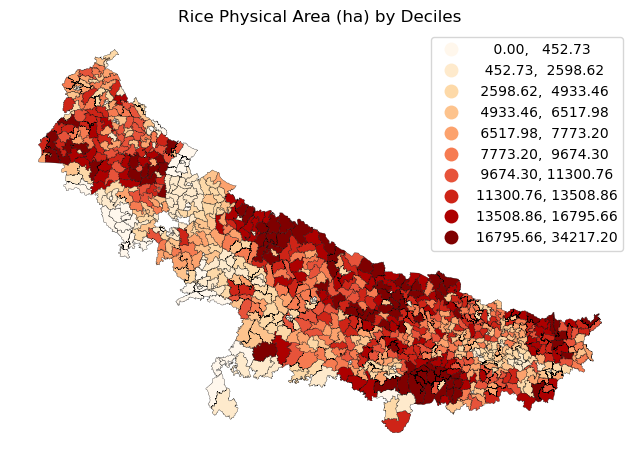

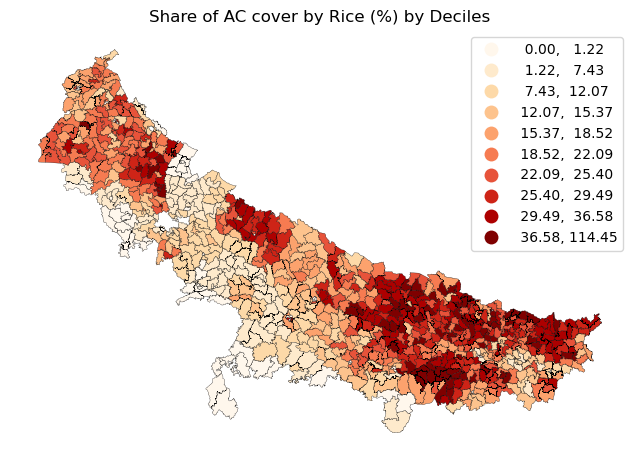

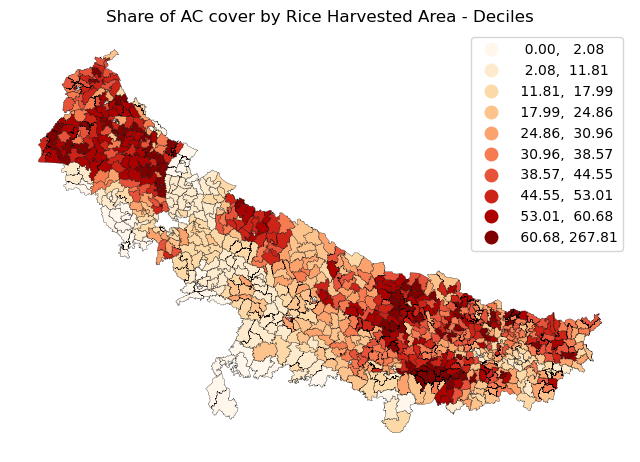

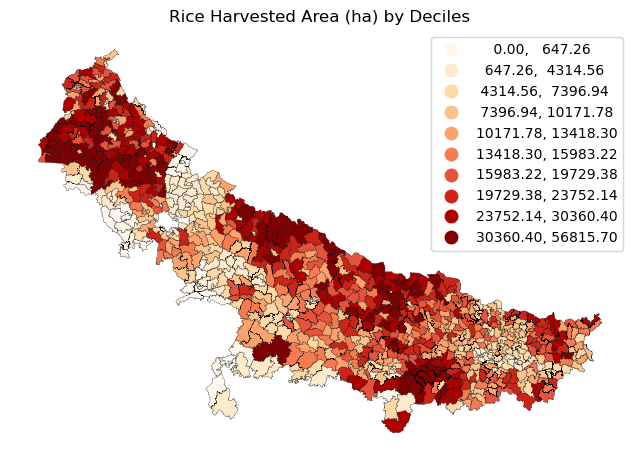

<Axes: >

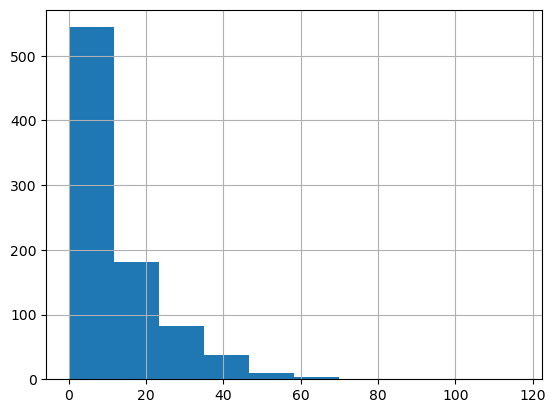

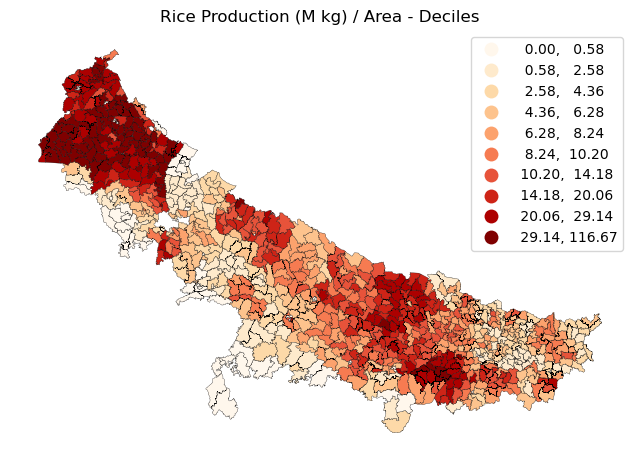

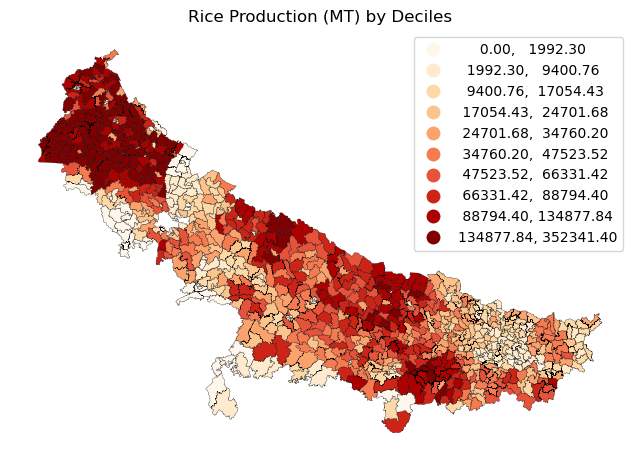

Index(['ac_uq_id', 'OBJECTID', 'dist_info', 'urban_shar', 'acpost08ID',
       'ac08_id', 'ac08_name', 'pc01_state', 'pc01_distr', 'pc01_sta_1',
       'pc01_dis_1', 'tr_ac_name', 'share_agri', 'share_ag_1', 'share_cult',
       'share_cu_1', 'agri_culti', 'share_cul_', 'share_cu_2', 'pc11_pca_m',
       'pc11_pca_t', 'pc11_pca_1', 'pc11_pca_2', 'median_sha', 'maj_agri_P',
       'median_s_1', 'maj_agri_W', 'median_s_2', 'maj_cul_ag', 'median_s_3',
       'maj_cul__1', 'median_hh_', 'inc_source', 'maj_hh_cul', 'polygon_ty',
       'geometry', 'rice_area_ha', 'rice_harvarea_ha', 'rice_prod_mt',
       'area_ac_m2', 'rice_area_ha_share', 'rice_harvarea_ha_share'],
      dtype='object')

/var/folders/r4/lwrzx5hs7d3cxk4p5zsy7zqh0000gp/T/ipykernel_57657/4242497126.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acs_rice_info['rice_area_aclvl_ahigh'] = 0
/var/folders/r4/lwrzx5hs7d3cxk4p5zsy7zqh0000gp/T/ipykernel_57657/4242497126.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acs_rice_info['rice_harvarea_aclvl_ahigh'] = 0


In [30]:
acs_rice = gpd.overlay(gdf, acs,keep_geom_type=True)

acs_ricearea = acs_rice.groupby(['ac_uq_id'], as_index = False)['RICE_A'].sum()

acs_ricearea.columns = ['ac_uq_id', 'rice_area_ha']

In [90]:
acs_riceindiaharvarea = gpd.overlay(riceindiaharvarea_gdf, acs,keep_geom_type=True)

acs_riceharvarea = acs_riceindiaharvarea.groupby(['ac_uq_id'], as_index = False)['RICE_A'].sum()

acs_riceharvarea.columns = ['ac_uq_id', 'rice_harvarea_ha']

In [91]:
acs_riceindiaprod = gpd.overlay(riceindiaprod_gdf, acs,keep_geom_type=True)

acs_acs_riceprod = acs_riceindiaprod.groupby(['ac_uq_id'], as_index = False)['RICE_A'].sum()

acs_acs_riceprod.columns = ['ac_uq_id', 'rice_prod_mt']

In [16]:
acs_rice_info = acs.merge(acs_ricearea, on = 'ac_uq_id', how = 'left') \
    .merge(acs_riceharvarea, on = 'ac_uq_id', how = 'left') \
    .merge(acs_acs_riceprod, on = 'ac_uq_id', how = 'left').drop(['geometry'], axis = 1)

In [22]:
import numpy as np

In [25]:
acs_rice_info['rice_area_ha'] = acs_rice_info.rice_area_ha.replace(np.nan, 0)
acs_rice_info['rice_harvarea_ha'] = acs_rice_info.rice_harvarea_ha.replace(np.nan, 0)
acs_rice_info['rice_prod_mt'] = acs_rice_info.rice_prod_mt.replace(np.nan, 0)

In [26]:
acs_rice_info.to_csv("../data_output/intermediate/9_rice_info_ac_lvl.csv", index = False)

In [104]:
import numpy as np


In [108]:
acs_final = acs.merge(acs_ricearea, on = 'ac_uq_id', how = 'left') \
    .merge(acs_riceharvarea, on = 'ac_uq_id', how = 'left') \
    .merge(acs_acs_riceprod, on = 'ac_uq_id', how = 'left')
acs_final['rice_area_ha'] = acs_final.rice_area_ha.replace(np.nan, 0)
acs_final['rice_harvarea_ha'] = acs_final.rice_harvarea_ha.replace(np.nan, 0)
acs_final['rice_prod_mt'] = acs_final.rice_prod_mt.replace(np.nan, 0)

In [109]:
acs_final = gpd.GeoDataFrame(acs_final, geometry = 'geometry')
acs_final.crs = 4326

In [110]:
acs_final.ac_uq_id.is_unique

True

In [113]:
figures = "/Users/ar8787/Dropbox/sa_fires/proj_bureaucrats_farms/tex/paper/figures"

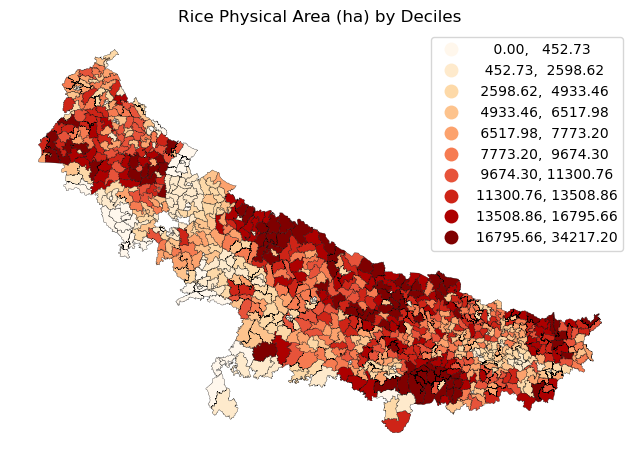

In [114]:
import mapclassify          # pip install mapclassify
import matplotlib.pyplot as plt

ax = acs_final.plot(
    column="rice_area_ha",
    scheme="Quantiles",    # break into equal‑count bins
    k=10,                    # number of quantiles
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    figsize=(8, 6),
)
ax.set_title("Rice Physical Area (ha) by Deciles")
ax.set_axis_off()
plt.show()




# 2) grab its Figure and save
fig = ax.get_figure()
fig.savefig(
    f"{figures}/rice_area_quantiles.png",  # file name
    dpi=300,                 # resolution
    bbox_inches="tight"      # trim extra whitespace
)

In [125]:
acs_final['area_ac_m2'] = acs_final.to_crs(7755).area

In [132]:
acs_final['rice_area_ha_share'] = acs_final['rice_area_ha'] * 10000 * 100/acs_final['area_ac_m2']

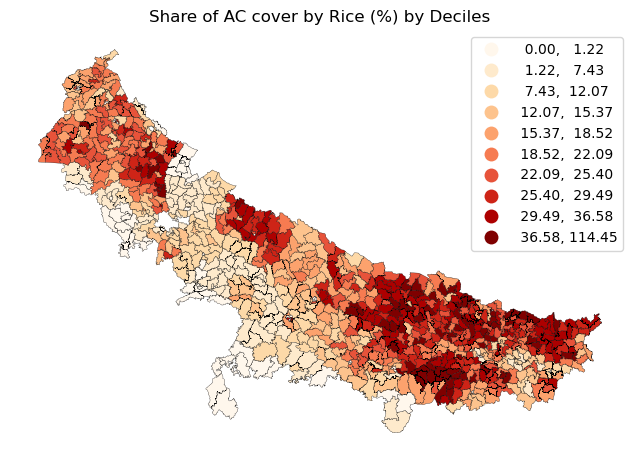

In [133]:
import mapclassify          # pip install mapclassify
import matplotlib.pyplot as plt

ax = acs_final.plot(
    column="rice_area_ha_share",
    scheme="Quantiles",    # break into equal‑count bins
    k=10,                    # number of quantiles
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    figsize=(8, 6),
)
ax.set_title("Share of AC cover by Rice (%) - Deciles")
ax.set_axis_off()
plt.show()




# 2) grab its Figure and save
fig = ax.get_figure()
fig.savefig(
    f"{figures}/rice_area_ha_share_quantiles.png",  # file name
    dpi=300,                 # resolution
    bbox_inches="tight"      # trim extra whitespace
)

In [134]:
acs_final['rice_harvarea_ha_share'] = acs_final['rice_harvarea_ha'] * 10000 * 100/acs_final['area_ac_m2']

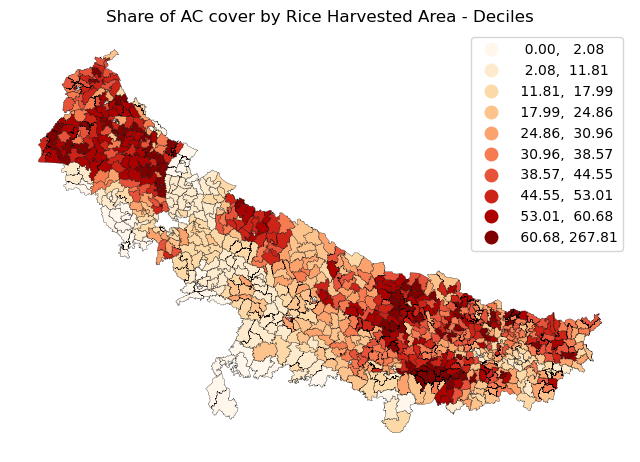

In [136]:
import mapclassify          # pip install mapclassify
import matplotlib.pyplot as plt

ax = acs_final.plot(
    column="rice_harvarea_ha_share",
    scheme="Quantiles",    # break into equal‑count bins
    k=10,                    # number of quantiles
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    figsize=(8, 6),
)
ax.set_title("Share of AC cover by Rice Harvested Area - Deciles")
ax.set_axis_off()
plt.show()




# 2) grab its Figure and save
fig = ax.get_figure()
fig.savefig(
    f"{figures}/rice_harvarea_ha_share_quantiles.png",  # file name
    dpi=300,                 # resolution
    bbox_inches="tight"      # trim extra whitespace
)

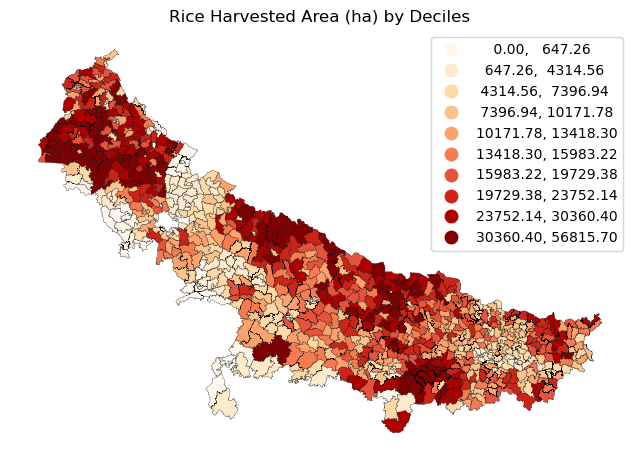

In [135]:
import mapclassify          # pip install mapclassify
import matplotlib.pyplot as plt

ax = acs_final.plot(
    column="rice_harvarea_ha",
    scheme="Quantiles",    # break into equal‑count bins
    k=10,                    # number of quantiles
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    figsize=(8, 6),
)
ax.set_title("Rice Harvested Area (ha) by Deciles")
ax.set_axis_off()
plt.show()




# 2) grab its Figure and save
fig = ax.get_figure()
fig.savefig(
    f"{figures}/rice_harvarea_ha_quantiles.png",  # file name
    dpi=300,                 # resolution
    bbox_inches="tight"      # trim extra whitespace
)

In [152]:
acs_final['rice_harvarea_ha_share'] = acs_final['rice_prod_mt'] * 1000 * 100/acs_final['area_ac_m2']

<Axes: >

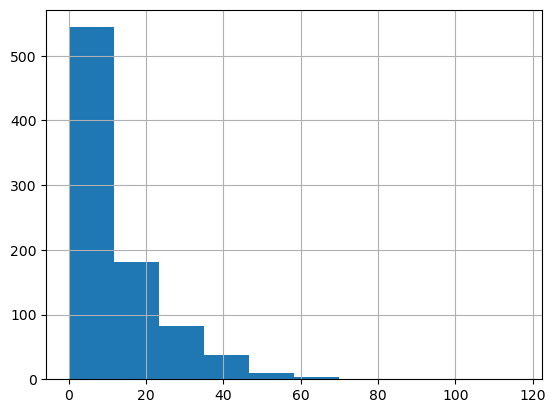

In [153]:
acs_final['rice_harvarea_ha_share'].hist()

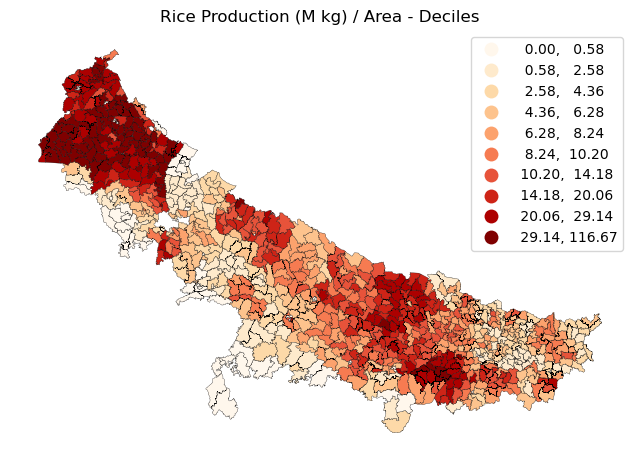

In [154]:
import mapclassify          # pip install mapclassify
import matplotlib.pyplot as plt

ax = acs_final.plot(
    column="rice_harvarea_ha_share",
    scheme="Quantiles",    # break into equal‑count bins
    k=10,                    # number of quantiles
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    figsize=(8, 6),
)
ax.set_title("Rice Production (M kg) / Area - Deciles")
ax.set_axis_off()
plt.show()




# 2) grab its Figure and save
fig = ax.get_figure()
fig.savefig(
    f"{figures}/rice_harvarea_ha_share_quantiles.png",  # file name
    dpi=300,                 # resolution
    bbox_inches="tight"      # trim extra whitespace
)

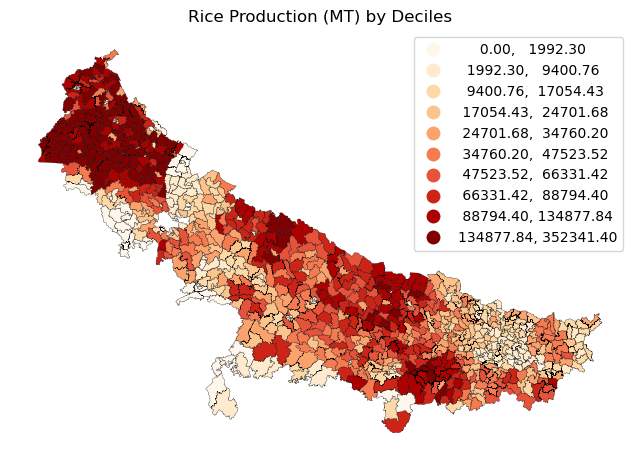

In [118]:
import mapclassify          # pip install mapclassify
import matplotlib.pyplot as plt

ax = acs_final.plot(
    column="rice_prod_mt",
    scheme="Quantiles",    # break into equal‑count bins
    k=10,                    # number of quantiles
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    figsize=(8, 6),
)
ax.set_title("Rice Production (MT) by Deciles")
ax.set_axis_off()
plt.show()




# 2) grab its Figure and save
fig = ax.get_figure()
fig.savefig(
    f"{figures}/rice_prod_mt_quantiles.png",  # file name
    dpi=300,                 # resolution
    bbox_inches="tight"      # trim extra whitespace
)

In [138]:
acs_final.columns

Index(['ac_uq_id', 'OBJECTID', 'dist_info', 'urban_shar', 'acpost08ID',
       'ac08_id', 'ac08_name', 'pc01_state', 'pc01_distr', 'pc01_sta_1',
       'pc01_dis_1', 'tr_ac_name', 'share_agri', 'share_ag_1', 'share_cult',
       'share_cu_1', 'agri_culti', 'share_cul_', 'share_cu_2', 'pc11_pca_m',
       'pc11_pca_t', 'pc11_pca_1', 'pc11_pca_2', 'median_sha', 'maj_agri_P',
       'median_s_1', 'maj_agri_W', 'median_s_2', 'maj_cul_ag', 'median_s_3',
       'maj_cul__1', 'median_hh_', 'inc_source', 'maj_hh_cul', 'polygon_ty',
       'geometry', 'rice_area_ha', 'rice_harvarea_ha', 'rice_prod_mt',
       'area_ac_m2', 'rice_area_ha_share', 'rice_harvarea_ha_share'],
      dtype='object')

In [146]:
acs_rice_info = acs_final[['ac_uq_id', 'rice_area_ha','rice_harvarea_ha','rice_prod_mt', 
                          'rice_area_ha_share', 'rice_harvarea_ha_share']]
acs_rice_info.columns = ['ac_uq_id', 'rice_area_ha_aclvl', 'rice_harvarea_ha_aclvl', 'rice_prod_mt_aclvl', 
                        'rice_area_share_aclvl', 'rice_harvarea_share_aclvl']

medval = acs_rice_info['rice_area_ha_aclvl'].median()
acs_rice_info['rice_area_aclvl_ahigh'] = 0
acs_rice_info.loc[ acs_rice_info.rice_area_ha_aclvl > medval, 'rice_area_aclvl_ahigh' ] = 1

medval = acs_rice_info['rice_harvarea_ha_aclvl'].median()
acs_rice_info['rice_harvarea_aclvl_ahigh'] = 0
acs_rice_info.loc[ acs_rice_info.rice_harvarea_ha_aclvl > medval, 'rice_harvarea_aclvl_ahigh' ] = 1

/var/folders/r4/lwrzx5hs7d3cxk4p5zsy7zqh0000gp/T/ipykernel_57657/4242497126.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acs_rice_info['rice_area_aclvl_ahigh'] = 0
/var/folders/r4/lwrzx5hs7d3cxk4p5zsy7zqh0000gp/T/ipykernel_57657/4242497126.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  acs_rice_info['rice_harvarea_aclvl_ahigh'] = 0


In [147]:
acs_rice_info.to_stata("../data_output/intermediate/rice_info_ac_lvl.dta")